In [ ]:
{
  "architectures": [
    "Qwen3MoeForCausalLM" #模型类型：Qwen3 的 MoE（混合专家） 因果语言模型
  ],
  "attention_bias": false, #  QKV 投影不加 bias（节省参数和计算）
  "attention_dropout": 0.0, #  注意力 dropout 为 0（推理不 drop）
  "bos_token_id": 151643, #  BOS token ID
  "decoder_sparse_step": 1,  # 每一层都是 MoE 层（每隔 1 层稀疏化，= 全部层）
  "eos_token_id": 151645, #  EOS token ID
  "head_dim": 128, ## 每个头的维度  每个注意力头的维度（hidden_size / num_attention_heads = 2048/32）
  "hidden_act": "silu", # 激活函数：SiLU（也叫 Swish）
  "hidden_size": 2048, #  每个 token 的隐藏层维度（核心宽度）
  "initializer_range": 0.02,#  权重初始化标准差（训练时用）
  "intermediate_size": 6144, # FFN 层的膨胀维度（hidden_size × 3）
  "max_position_embeddings": 40960, # 最大上下文长度：40K tokens
  "max_window_layers": 48,# 如果用滑动窗口，最多 48 层可使用（当前未启用） 
  "mlp_only_layers": [],## 没有纯 FFN 层（空列表，全部层都是 MoE）
  "model_type": "qwen3_moe", # │ HuggingFace 模型类型标识
  "moe_intermediate_size": 768,# 每个专家的 FFN 隐藏层维度（比共享 FFN 小很多）
  "norm_topk_prob": true, #  对 top-k 专家的概率做归一化后再加权
  "num_attention_heads": 32, ##Q头的数量，每层的注意力头数
  "num_experts": 128, #  总共 128 个专家（FFN 专家）
  "num_experts_per_tok": 8, # 每个 token 激活其中的 8 个专家（top-8 路由）
  "num_hidden_layers": 48, # Transformer 总层数
  "num_key_value_heads": 4, ## K-V头的数量  KV 头数，这里是 GQA（Grouped Query Attention），每 8 个 Q 头共享 1 对 KV 头
  "output_router_logits": false, #  推理时不输出路由 logits（不需要算 aux loss）
  "rms_norm_eps": 1e-06, #  RMS Norm 的 epsilon（防止除零）
  "rope_scaling": null, # 未使用动态 RoPE 缩放（原生就已支持 40960 长度）
  "rope_theta": 1000000.0,#  RoPE 基频（高频 → 更好的长距离衰减 → 支持长上下文）
  "router_aux_loss_coef": 0.001, # 训练时的负载均衡辅助损失系数（推理时不使用）
  "sliding_window": null, #  不使用滑动窗口注意力（全局注意力）
  "tie_word_embeddings": false, # 输入和输出 embedding 不共享
  "torch_dtype": "bfloat16", # 推理/加载时的默认精度：BF16（节省显存，数值范围大）
  "transformers_version": "4.51.0",
  "use_cache": true, #   推理时缓存 KV 状态（自回归生成必需）
  "use_sliding_window": false,
  "vocab_size": 151936 #  词表大小（~152K tokens）
}

# 一、Embedding
- Embedding层的参数量计算=vocab_size × embedding_dim
- 为什么是这样？Embedding本身是一个巨大的查找表，是一个二维矩阵
- 行数 → 词表大小 V（vocab_size）：每个 token 都有一行对应的向量，共 V 个 token
- 列数 → 嵌入维度 d（embedding_dim / hidden_dim / d_model）：每个向量的长度

In [11]:
# Embedding
vocab_size = 151936
embedding_dim = hidden_size = hidden_dim = d_model  = 2048
EmbeddingParams = vocab_size * embedding_dim
print(f"EmbeddingParams={EmbeddingParams}")

EmbeddingParams=311164928


# 二、RMSNorm
- RMSNorm的公式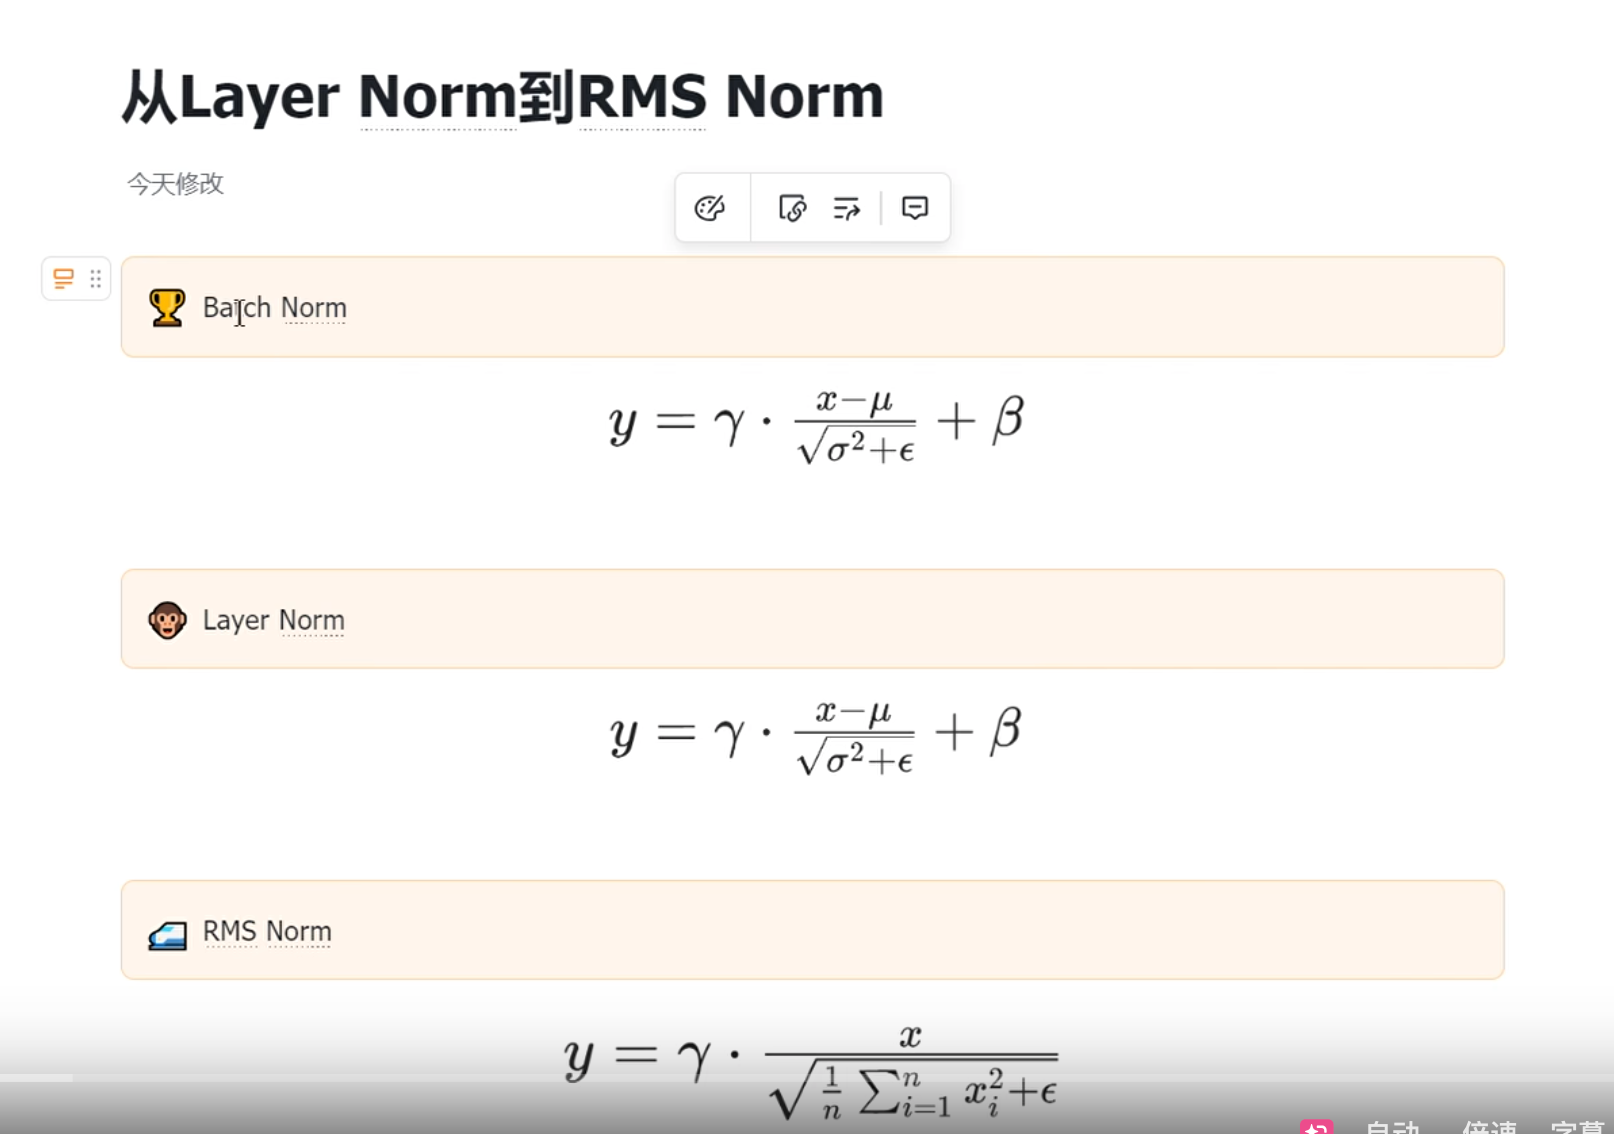

In [ ]:
╔══════════════════════════════════════════════════════════════════╗
║                        RMSNorm 前向计算                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  输入向量 x  维度 d=4                                            ║
║  ┌───────┬────────┬───────┬───────┐                              ║
║  │ x₁    │  x₂    │  x₃   │  x₄   │                              ║
║  │ 2.0   │ -4.0   │ 4.0   │ 2.0   │                              ║
║  └───────┴────────┴───────┴───────┘                              ║
║    │                                                              ║
║    ▼                                                              ║
║  Step 1:  x² → mean → sqrt                                       ║
║  ┌───────┬────────┬───────┬───────┐                              ║
║  │ 4.0   │ 16.0   │ 16.0  │ 4.0   │   sum=40  mean=10           ║
║  └───────┴────────┴───────┴───────┘                              ║
║                                                                  ║
║              RMS = √10 ≈ 3.162    ← 一个标量                      ║
║    │                                                              ║
║    ▼                                                              ║
║  Step 2:  x / RMS                                                ║
║  ┌───────┬────────┬───────┬───────┐                              ║
║  │ 0.632 │ -1.265 │ 1.265 │ 0.632 │   ← 归一化后 RMS=1          ║
║  └───────┴────────┴───────┴───────┘                              ║
║    │                                                              ║
║    ▼                                                              ║
║  Step 3:  ⊙ γ（逐元素乘）                                        ║
║  ┌───────┬────────┬───────┬───────┐   ┌───────┬───────┬───────┬──┐
║  │ 0.632 │ -1.265 │ 1.265 │ 0.632 │ × │ γ₁=1.0│ γ₂=1.0│ γ₃=1.0│..│
║  └───────┴────────┴───────┴───────┘   └───────┴───────┴───────┴──┘
║    │                                                                 ║
║    ▼                                                                 ║
║  输出 y                                                              ║
║  ┌───────┬────────┬───────┬───────┐                                 ║
║  │ 0.632 │ -1.265 │ 1.265 │ 0.632 │  (γ 全 1 时不变)               ║
║  └───────┴────────┴───────┴───────┘                                 ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  LayerNorm vs RMSNorm 差异一览                                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  LayerNorm:   x' = (x - μ) / σ    →    y = γ ⊙ x' + β               ║
║  RMSNorm:     x' =  x      / RMS  →    y = γ ⊙ x'        ← 省两步   ║X
║                                                                      ║
║  计算量对比（d=4096，一个向量）                                      ║
║  ┌──────────────┬──────────────┬───────────┐                         ║
║  │ 操作         │ LayerNorm    │ RMSNorm   │                         ║
║  ├──────────────┼──────────────┼───────────┤
║  │ 求均值       │ ✓ (4096次+) │ ✗         │                         ║
║  │ 求方差       │ ✓ (4096次+) │ ✗         │
║  │ 求 RMS(平方) │ ✗ (间接算)  │ ✓ (4096次)│                         ║
║  │ 减均值       │ ✓ (4096次)  │ ✗         │
║  │ 除缩放因子   │ ✓ (4096次)  │ ✓ (4096次)│                         ║
║  │ 乘 γ         │ ✓ (4096次)  │ ✓ (4096次)│
║  │ 加 β         │ ✓ (4096次)  │ ✗         │                         ║
║  ├──────────────┼──────────────┼───────────┤
║  │ 总元素操作   │ ~24K         │ ~16K      │  ≈ 节省 1/3            ║
║  │ 可学习参数   │ 2d = 8192    │ d = 4096  │  ≈ 节省 1/2
║  └──────────────┴──────────────┴───────────┘                         ║
╚═════════════════════════════════════════════════════════


In [10]:
RMSNormParams = embedding_dim = hidden_size = hidden_dim = d_model
print(f"RMSNormParams={RMSNormParams}")

RMSNormParams=2048


二、RoPE
- 里面没有参数信息

# 三、Grouped-Query Attention 

In [ ]:
# self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
# self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
# self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
# nn.Linear_params = in * out + out

In [ ]:
# W_query_Params = d_in * d_out + dout 
# W_key_Params = d_in * num_kv_groups * head_dim + num_kv_groups * head_dim
# W_value_Params = d_in * num_kv_groups * head_dim + num_kv_groups * head_dim

In [24]:
#   "hidden_size": 2048, #  每个 token 的隐藏层维度（核心宽度）
#   "num_attention_heads": 32, ##Q头的数量，每层的注意力头数
#   "head_dim": 128, ## 每个头的维度  每个注意力头的维度（hidden_size / num_attention_heads = 2048/32）
#   "num_key_value_heads": 4, ## K-V头的数量  KV 头数，这里是 GQA（Grouped Query Attention），每 8 个 Q 头共享 1 对 KV 头
# 2048 * 4096
W_query_Params = 2048 * (32 * 128)
print(f"W_query_Params = {W_query_Params}")
# 2048 * 512
W_key_Params = 2048 * (4 * 128)
print(f"W_key_Params = {W_key_Params}")
# 2048 * 512
W_value_Params = 2048 * (4 * 128)
print(f"W_value_Params = {W_value_Params}")
W_output_Params = 4096 * 2048

GQAParams = W_query_Params + W_key_Params + W_value_Params + W_output_Params
print(f"GQAParams = {GQAParams}")

W_query_Params = 8388608
W_key_Params = 1048576
W_value_Params = 1048576
GQAParams = 18874368


# RMSNorm2

In [23]:
RMSNorm2Params = embedding_dim = hidden_size = hidden_dim = d_model
print(f"RMSNorm2Params={RMSNorm2Params}")

RMSNorm2Params=2048


# MOE 

In [17]:
# router 其实是一个线性层，把2048降维为128个 Feed forward 
# router = nn.Linear(2048,128, bias=False, dtype=cfg["dtype"])
routerParams = 2048 * 128 
print(f"routerParams = {routerParams}")

routerParams = 262144


In [28]:
# Feed forward
# Linear Layer 

moe_intermediate_size = 768
upParams = 2048 * 768
gateParams = 2048 * 768 
downParams = 2048 * 768
FFNParms = upParams + gateParams + downParams
print(f"FFNParms = {FFNParms}")
moeParams = FFNParms * 128  + routerParams
print(f"moeParams = {moeParams}")

FFNParms = 4718592
moeParams = 604241920


# Final RMSNorm

In [21]:
fnialRMSNormParams = 2048

In [22]:
linerOutputLayerParams = 2048 * vocab_size
print(f"linerOutputLayerParams = {linerOutputLayerParams}")

linerOutputLayerParams = 311164928


In [30]:
# 总参数量计算
allParams = EmbeddingParams + linerOutputLayerParams + (RMSNormParams + GQAParams + RMSNorm2Params + moeParams) * 48 + fnialRMSNormParams
print(f"allParams = {allParams}")

allParams = 30532110336


In [31]:
activeParams = EmbeddingParams + linerOutputLayerParams + (RMSNormParams + GQAParams + RMSNorm2Params + (FFNParms * 8 + routerParams)) * 48 + fnialRMSNormParams
print(f"activeParams = {activeParams}")

activeParams = 3353020416
